# 3주차. REST 응답, DataFrame, UI 함수

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |

이 노트북은 수업 주차 흐름을 참고해 우리 방식으로 재구성한 실행형 설명 자료입니다. 외부 서비스 호출 없이 실행되도록 작은 샘플 데이터를 사용합니다.

## REST 응답 구조
REST API의 JSON 응답은 리스트와 딕셔너리의 조합입니다. DataFrame으로 바꾸면 필터링과 통계 계산이 쉬워집니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

api_rows = [
    {"id": 1, "user_id": 1, "title": "collect data", "done": True},
    {"id": 2, "user_id": 1, "title": "clean table", "done": False},
    {"id": 3, "user_id": 2, "title": "make chart", "done": True},
    {"id": 4, "user_id": 3, "title": "write summary", "done": False},
]
tasks = pd.DataFrame(api_rows)
tasks["status"] = tasks["done"].map({True: "done", False: "todo"})
tasks

,id,user_id,title,done,status
0,1,1,collect data,True,done
1,2,1,clean table,False,todo
2,3,2,make chart,True,done
3,4,3,write summary,False,todo


## UI에 연결할 함수
Gradio 같은 UI는 결국 함수를 호출합니다. 먼저 순수 함수로 필터링과 요약을 만들면 화면이 없어도 검증할 수 있습니다.

In [2]:
def filter_tasks(user_id=None, status=None):
    result = tasks.copy()
    if user_id is not None:
        result = result[result["user_id"] == user_id]
    if status:
        result = result[result["status"] == status]
    return result.reset_index(drop=True)

def summarize_tasks():
    return tasks.groupby("status", as_index=False).agg(count=("id", "count"))

filtered = filter_tasks(user_id=1)
summary = summarize_tasks()

assert len(filtered) == 2
assert summary["count"].sum() == len(tasks)
display(filtered)
display(summary)

,id,user_id,title,done,status
0,1,1,collect data,True,done
1,2,1,clean table,False,todo


,status,count
0,done,2
1,todo,2


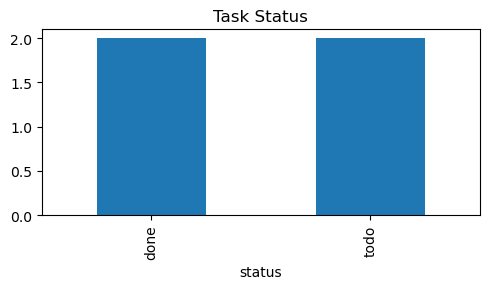

In [3]:
ax = summarize_tasks().plot(kind="bar", x="status", y="count", legend=False, figsize=(5, 3), title="Task Status")
plt.tight_layout()
plt.show()